## Visualization of the geodesics and generated Image

### Setting the parameters of the camera and the problem

In [1]:
include("../src/main.jl")


main (generic function with 1 method)

In [2]:
#Analytic parameters


## REMEMBER TO CHANGE BLACK HOLE MASS IN PARAMETERS.JL

#Setting up the parameters
#Observer distance in Rg
ro = 1000.0
#Observer inclination in degrees
th = 60.0

#Observer azimuth in degrees
phi = 0.0

# Size of the screen in Rg in both directions
DXsize = 30.0
DYsize = 30.0

# Observer fov in radians (this can be understood as size of the plane camera sees over the distance ro)
# This should be atan, but for small angles it is approximately equal to the angle itself
fovx = DXsize/ro
fovy = DYsize/ro

# Number of pixels in the x and y direction. The number of geodesics calculated will be res^2
res = 80
pixels_x = 80
pixels_y = 80
# Distance to the source in parsecs
SourceD = 7.778e3 * PC
bhspin = 0.9
Rout = 1000.0
Rstop = 10000.0
Rh = 1 + sqrt(1. - bhspin * bhspin);

cstartx = [0.0, log(Rh), 0.0, 0.0]
cstopx = [0.0, log(1000.0), 1.0, 2.0 * π]
# Frequency observed by the camera in Hz
freq = 230e9


2.3e11

In [6]:
#THIN DISK PARAMETERS


## REMEMBER TO CHANGE BLACK HOLE MASS IN PARAMETERS.JL

#Setting up the parameters
#Observer distance in Rg
ro = 10000.0
#Observer inclination in degrees
th = 60.0

#Observer azimuth in degrees
phi = 0.0

# Size of the screen in Rg in both directions
DXsize = 40.0
DYsize = 40.0

# Observer fov in radians (this can be understood as size of the plane camera sees over the distance ro)
# This should be atan, but for small angles it is approximately equal to the angle itself
fovx = DXsize/ro
fovy = DYsize/ro

# Number of pixels in the x and y direction. The number of geodesics calculated will be res^2
res = 256
pixels_x = 256
pixels_y = 256

# Distance to the source in parsecs
SourceD = 0.05 * PC
Rout = 1000.0
Rstop = 10000.0

# Frequency observed by the camera in Hz
freq = 2.417989e17#230e9

2.417989e17

### Set the camera and calculate the geodesics

In [3]:
# Find camera in native coordinates
Xcamera = MVec4(camera_position(ro, th, phi, bhspin, Rout))

# Scales the intensity of each pixel by the real size of each pixel
scale_factor = CalculateScaleFactor(DXsize, DYsize, pixels_x, pixels_y, SourceD, L_unit)

maxnstep = 8000
# Generate geodesics
# integrate_emission_flag setted to false signals that the output of the function will be the trajectory and not the Image
trajectory = CalculateGeodesics(Xcamera, fovx, fovy, freq, maxnstep, pixels_x, pixels_y, bhspin, Rout, Rstop);

Utilizing 1 threads for geodesic calculation.
Processing row 0 out of 80
Processing row 1 out of 80
Processing row 2 out of 80
Processing row 3 out of 80
Processing row 4 out of 80
Processing row 5 out of 80
Processing row 6 out of 80
Processing row 7 out of 80
Processing row 8 out of 80
Processing row 9 out of 80
Processing row 10 out of 80
Processing row 11 out of 80
Processing row 12 out of 80
Processing row 13 out of 80
Processing row 14 out of 80
Processing row 15 out of 80
Processing row 16 out of 80
Processing row 17 out of 80
Processing row 18 out of 80
Processing row 19 out of 80
Processing row 20 out of 80
Processing row 21 out of 80
Processing row 22 out of 80
Processing row 23 out of 80
Processing row 24 out of 80
Processing row 25 out of 80
Processing row 26 out of 80
Processing row 27 out of 80
Processing row 28 out of 80
Processing row 29 out of 80
Processing row 30 out of 80
Processing row 31 out of 80
Processing row 32 out of 80
Processing row 33 out of 80
Processing r

# Plotting

### Plotting the geodesics

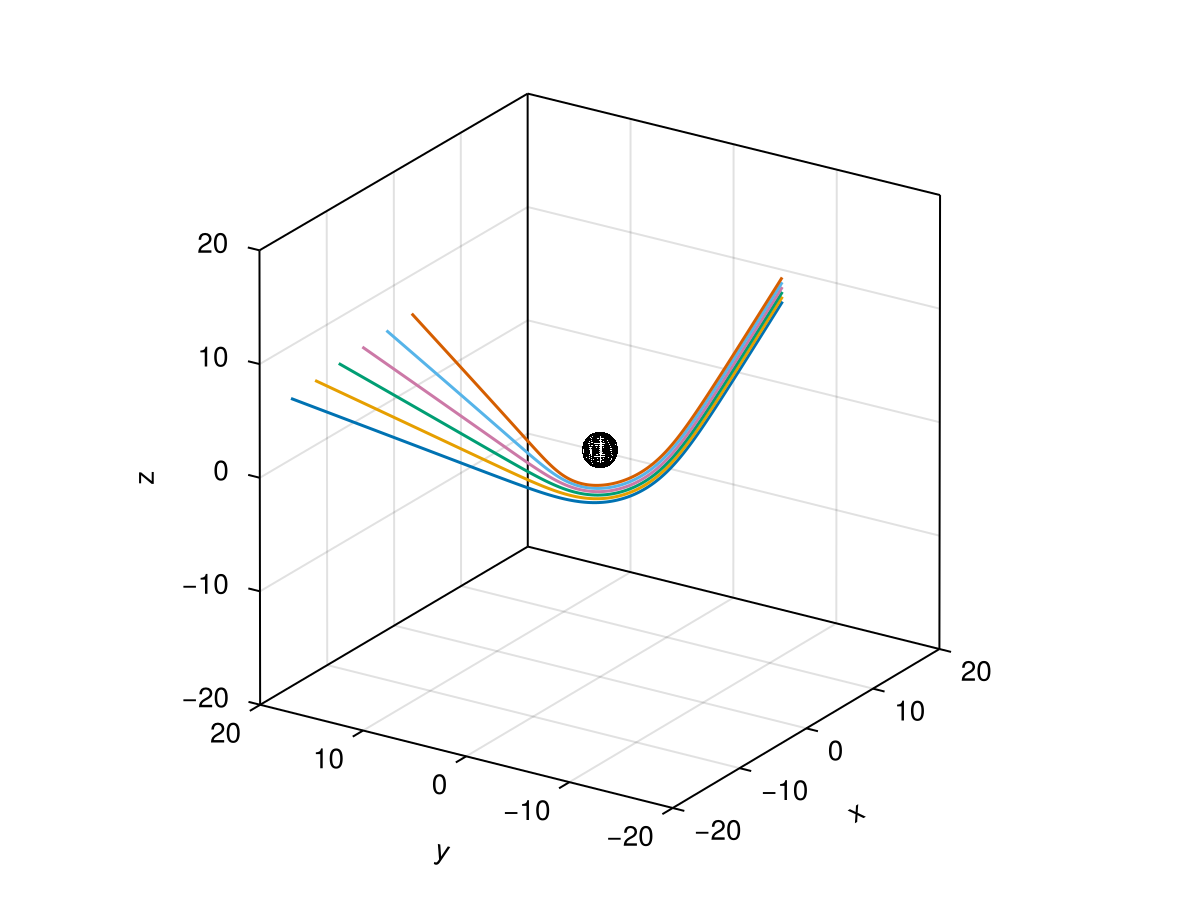

In [4]:
using CairoMakie

fig = Figure()
ax = Axis3(fig[1,1], aspect=(1,1,1), azimuth=10)

# Scale of the figure
scale = 20
xlims!(ax, -scale, scale)
ylims!(ax, -scale, scale)
zlims!(ax, -scale, scale)

# Plot the BH as a sphere mesh
function sphere_mesh(center, radius, n=30)
    θ = range(0, π, length=n)
    φ = range(0, 2π, length=n)
    xs = Float32[]
    ys = Float32[]
    zs = Float32[]
    for th in θ, ph in φ
        push!(xs, center[1] + radius * sin(th) * cos(ph))
        push!(ys, center[2] + radius * sin(th) * sin(ph))
        push!(zs, center[3] + radius * cos(th))
    end
    xs, ys, zs
end

xs, ys, zs = sphere_mesh((0.0, 0.0, 0.0), Rh)
mesh!(ax, xs, ys, zs, color=:black)

#Plotting the trajectory from pixel row 30 columns 30 to 35
i = 30
for j in 30:35
    traj = trajectory[i, j]
    pts = []
    for t in traj
        r = bl_coord(t.X)[1]
        th = bl_coord(t.X)[2]
        phi = t.X[4]
        if r >= Rh
            push!(pts, (r * sin(th) * cos(phi),
                        r * sin(th) * sin(phi),
                        r * cos(th)))
        end
    end
    if !isempty(pts)
        lines!(ax, pts, linestyle=:solid)
    end
end
fig

### Plotting the final Image

In [5]:
#Integrate radiative transfer equation based on the trajectory array
Image = IpoleGeoIntensityIntegration(trajectory, freq, pixels_x, pixels_y, scale_factor, bhspin)

Processing row 0 out of 80
Processing row 1 out of 80
Processing row 2 out of 80
Processing row 3 out of 80
Processing row 4 out of 80
Processing row 5 out of 80
Processing row 6 out of 80
Processing row 7 out of 80
Processing row 8 out of 80
Processing row 9 out of 80
Processing row 10 out of 80
Processing row 11 out of 80
Processing row 12 out of 80
Processing row 13 out of 80
Processing row 14 out of 80
Processing row 15 out of 80
Processing row 16 out of 80
Processing row 17 out of 80
Processing row 18 out of 80
Processing row 19 out of 80
Processing row 20 out of 80
Processing row 21 out of 80
Processing row 22 out of 80
Processing row 23 out of 80
Processing row 24 out of 80
Processing row 25 out of 80
Processing row 26 out of 80
Processing row 27 out of 80
Processing row 28 out of 80
Processing row 29 out of 80
Processing row 30 out of 80
Processing row 31 out of 80
Processing row 32 out of 80
Processing row 33 out of 80
Processing row 34 out of 80
Processing row 35 out of 80
Pr

80×80 Matrix{Float64}:
 5.00689e-8  5.96735e-8  7.07377e-8  …  1.89155e-7  1.68614e-7  1.49454e-7
 5.21897e-8  6.21765e-8  7.36722e-8     1.98501e-7  1.77254e-7  1.57378e-7
 5.43306e-8  6.4701e-8   7.66289e-8     2.07971e-7  1.86038e-7  1.6546e-7
 5.64871e-8  6.72416e-8  7.96016e-8     2.17539e-7  1.94942e-7  1.73678e-7
 5.86545e-8  6.97928e-8  8.25836e-8     2.27176e-7  2.03942e-7  1.82014e-7
 6.08281e-8  7.23488e-8  8.55682e-8  …  2.36853e-7  2.13013e-7  1.90442e-7
 6.30028e-8  7.49038e-8  8.85484e-8     2.46541e-7  2.22127e-7  1.98941e-7
 6.51736e-8  7.74517e-8  9.15171e-8     2.56206e-7  2.31255e-7  2.07483e-7
 6.73352e-8  7.99863e-8  9.44671e-8     2.65818e-7  2.40368e-7  2.16042e-7
 6.94823e-8  8.25015e-8  9.73911e-8     2.75342e-7  2.49435e-7  2.24591e-7
 7.16096e-8  8.49908e-8  1.00282e-7  …  2.84747e-7  2.58424e-7  2.331e-7
 7.37116e-8  8.7448e-8   1.03132e-7     2.93997e-7  2.67306e-7  2.4154e-7
 7.5783e-8   8.98668e-8  1.05934e-7     3.0306e-7   2.76046e-7  2.49882e-7
 ⋮    

In [6]:
#Outputting diagnostics
OutputStokesParameters(Image, freq, scale_factor, res, SourceD)

Image processing complete. Calculating total flux and averages...
Scale = 8.792336115740046e+00
imax = 29, jmax = 38, Imax = 9.694711695851555e-7, Iavg = 4.602771054897007e-7
Using freq_cgs = 2.3e11, Ftot = 0.025900230514210316
nuLnu = 4.3119966549062386e32


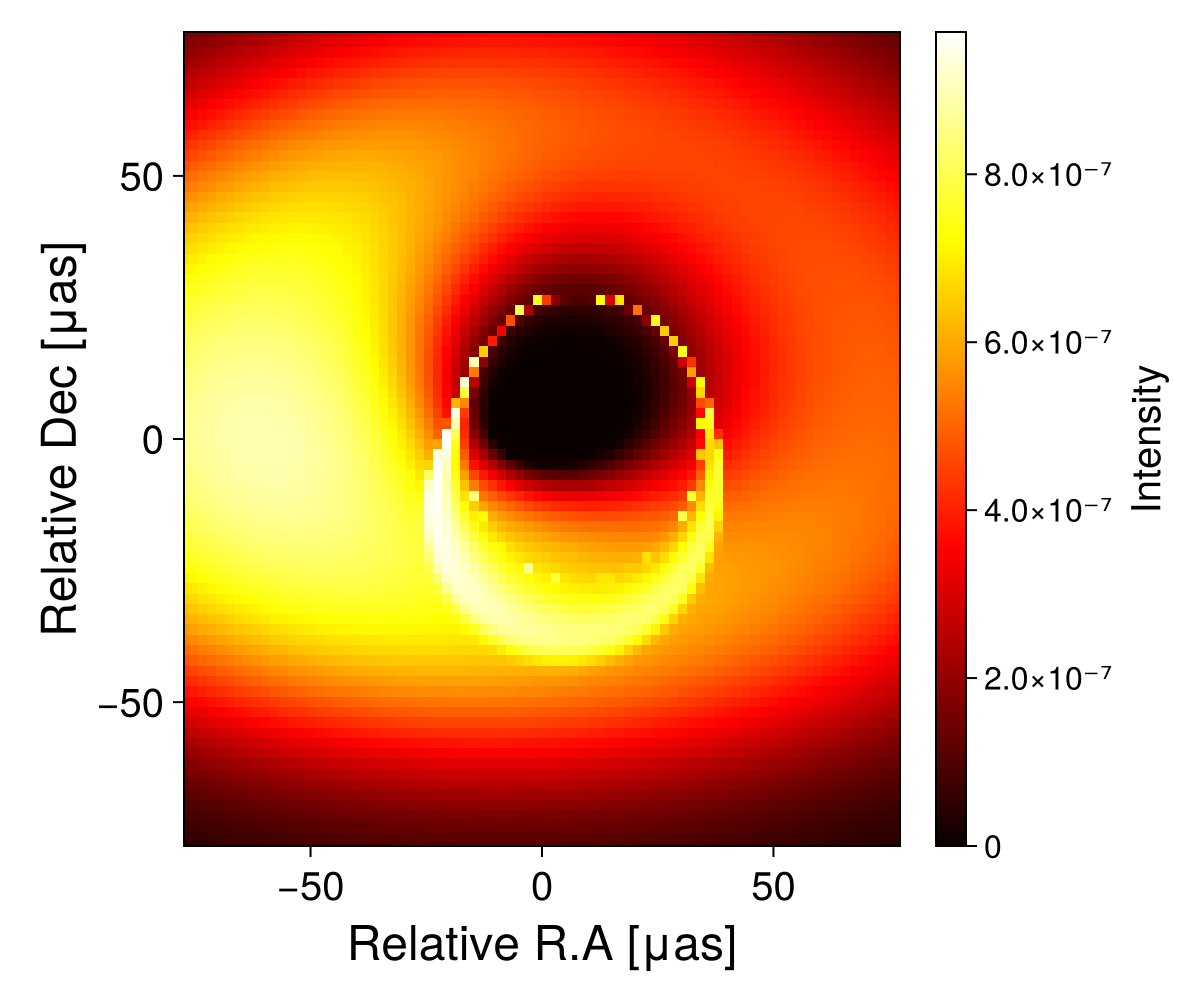

In [8]:
using CairoMakie
using Printf

d_kpc = 7.78
d_cm = d_kpc * 3.086e21           # distance in cm
fov_rg = 30                       # field of view in gravitational radii
half_fov_rg = fov_rg / 2

# Angular resolution
theta_rad = (half_fov_rg * L_unit) / d_cm   # half FOV in radians
theta_μas = theta_rad * MUAS_PER_RAD        # convert to μas
xlims = (-theta_μas, theta_μas)
ylims = (-theta_μas, theta_μas)

# Generate mock image (or load your 128x128 array here)
img = Image

# Axes
Ny, Nx = size(img)
x = range(xlims[1], xlims[2], length=Nx)
y = range(ylims[1], ylims[2], length=Ny)

# Plot
fig = Figure(size = (600, 500))
ax = Axis(fig[1, 1],
    xlabel = "Relative R.A [μas]",
    ylabel = "Relative Dec [μas]",
    xlabelsize=24,
    ylabelsize=24,
    xticklabelsize=20,
    yticklabelsize=20,
    limits = (xlims, ylims)
)

# Heatmap with color range
crange = extrema(img)
hm = heatmap!(ax, x, y, img; colormap=:hot, colorrange=crange)

# Colorbar
Colorbar(fig[1, 2], hm;
    label = "Intensity",
    labelsize = 20,
    ticklabelsize = 16,
    width = 15
)

fig
